## 1. Introdução ao dataset

O presente estudo realiza uma análise exploratória do conjunto de dados "Air Quality UCI". Este dataset é de grande relevância para a área de ciências ambientais e aprendizado de máquina, pois contém registros detalhados da qualidade do ar de uma cidade metropolitana italiana, coletados entre março de 2004 e fevereiro de 2005.

Os dados foram capturados por um dispositivo multisensor que media, em intervalos horários, a concentração de diversos poluentes atmosféricos, como monóxido de carbono (CO), benzeno (C6H6) e óxidos de nitrogênio (NOx), além de registrar condições meteorológicas como temperatura e umidade.

A análise deste conjunto de dados visa identificar padrões, distribuições e correlações entre as variáveis, fornecendo insights valiosos sobre a dinâmica da poluição do ar em um ambiente urbano. O entendimento dessas características é o primeiro passo para a construção de modelos preditivos e para a avaliação do impacto ambiental na saúde pública.

## 2. Descrição dataset

#### 2.1 Importando bibliotecas

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import warnings

#### 2.2 Configurações

In [33]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

warnings.filterwarnings('ignore')
# Add parent directory to sys.path for module imports
sys.path.append('..')

#### 2.2 Carregando dataset

In [34]:
# Carrega o dataset 
data_path = "../database/air_quality_uci.csv"
air_quality = pd.read_csv(data_path,
                          sep=";",
                          decimal=",", 
                          na_values=-200,
                          date_format="%d/%m/%Y %H.%M.%S",
                          parse_dates={"datetime": ["Date", "Time"]}, 
                          index_col="datetime")  

# Converting 'datetime' column to datetime format with error coercion
air_quality.index = pd.to_datetime(air_quality.index, format="%d/%m/%Y %H.%M.%S", errors="coerce")

# Remoção de duas colunas vazias que estão no final do dataset
air_quality = air_quality.iloc[:, :-2]

# Exibir 5 linhas aleatórias para verificar se foi carregado corretamente
print(f"Dataset shape: {air_quality.shape}")
print("Cabeçalho do DataFrame:")
air_quality.sample(5)

Dataset shape: (9471, 13)
Cabeçalho do DataFrame:


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-06-10 05:00:00,0.9,872.0,NaN,5.4,782.0,75.0,1001.0,76.0,1607.0,874.0,19.5,59.4,1.3328
2004-10-03 10:00:00,NaN,1250.0,NaN,10.7,1003.0,NaN,647.0,NaN,1638.0,1217.0,23.5,54.5,1.5553
2005-01-11 23:00:00,3.5,1433.0,NaN,16.2,1186.0,586.0,479.0,151.0,1497.0,1738.0,11.9,69.0,0.9568
2005-02-15 00:00:00,1.0,884.0,NaN,3.1,658.0,126.0,982.0,102.0,813.0,581.0,8.7,31.2,0.3521
2004-09-16 03:00:00,0.7,915.0,NaN,4.3,725.0,NaN,962.0,NaN,1485.0,845.0,20.2,73.8,1.7229


#### 2.3 Obter número de instâncias e variáveis

In [35]:
print("Dimensões:", air_quality.shape)  # linhas e colunas

Dimensões: (9471, 13)


In [36]:
print("Valores nulos por coluna:\n")
air_quality.isna().sum()

Valores nulos por coluna:



CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

#### 2.4 Listagem de variáveis

In [37]:
# Lista variáveis, tipos de dados e contagem de valores não nulos
print("Dataset Information:")
print("=" * 80)
air_quality.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9471 entries, 2004-03-10 18:00:00 to NaT
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       914 non-null    float64
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        7718 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        7715 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              8991 non-null   float64
 11  RH             8991 non-null   float64
 12  AH             8991 non-null   float64
dtypes: float64(13)
memory usage: 1.0 MB


#### 2.5 Contagem de valores nulos por variáveis

In [38]:
print("\nMissing Values:")
air_quality.isnull().sum()


Missing Values:


CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

In [39]:
print(f"\nTotal missing values: {air_quality.isnull().sum().sum()}")


Total missing values: 18183


### 2.6 Apagar linhas duplicadas

In [40]:
# drop duplicate rows
air_quality.drop_duplicates(inplace=True)

# 3. Estátisticas univariadas incondicionais

#### 3.1 Calculo da media
<span style="font-size: 15px;">A média, ou valor médio, é a medida de tendência central mais comum. No contexto do nosso dataset, ela nos dará um valor "típico" para cada sensor e medição ao longo de todo o período de coleta. </span>

In [41]:
# Cálculo da média para cada variável numérica
print("Média para cada variável:")
air_quality.mean(numeric_only=True)

Média para cada variável:


CO(GT)              2.152926
PT08.S1(CO)      1099.833166
NMHC(GT)          218.811816
C6H6(GT)           10.083105
PT08.S2(NMHC)     939.153376
NOx(GT)           246.896735
PT08.S3(NOx)      835.493605
NO2(GT)           113.091251
PT08.S4(NO2)     1456.264598
PT08.S5(O3)      1022.906128
T                  18.317829
RH                 49.234201
AH                  1.025530
dtype: float64

#### 3.2 Calculo do desvio padrao
<span style="font-size: 15px;">O desvio padrão nos diz o quão espalhados ou variáveis os dados são em torno dessa média. Um desvio padrão baixo significa que a maioria dos valores está muito próxima da média. Os dados são consistentes e previsíveis. Um desvio padrão alto significa que os valores estão muito espalhados. Há uma grande variação nas medições, com muitos valores longe da média. 
Para o nosso dataset, o desvio padrão vai nos ajudar a entender a volatilidade de cada poluente e condição climática.</span>

In [42]:
#Cálculo do desvio padrão para cada variável numérica
print("\nDesvio padrão para cada variável:")
air_quality.std(numeric_only=True)


Desvio padrão para cada variável:


CO(GT)             1.453265
PT08.S1(CO)      217.080037
NMHC(GT)         204.459921
C6H6(GT)           7.449820
PT08.S2(NMHC)    266.831429
NOx(GT)          212.979168
PT08.S3(NOx)     256.817320
NO2(GT)           48.370108
PT08.S4(NO2)     346.206794
PT08.S5(O3)      398.484288
T                  8.832116
RH                17.316892
AH                 0.403813
dtype: float64

#### 3.3 Describe

In [43]:
air_quality.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7673.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152926,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453265,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


#### 3.4 Calculo de skewness (Assimetria)
Enquanto a média e o desvio padrão nos dão informações sobre o centro e a dispersão, a skewness nos diz sobre a forma da distribuição.
- Skewness ≈ 0: A distribuição é quase simétrica. Os dados se espalham de maneira uniforme em ambos os lados da média. A curva parece um sino (distribuição normal).
- Skewness > 0: A distribuição tem uma "cauda" mais longa à direita. Isso significa que, embora a maioria dos valores esteja concentrada à esquerda, existem alguns valores extremamente altos que "puxam" a média para a direita.
- Skewness < 0: A distribuição tem uma "cauda" mais longa à esquerda. A maioria dos valores está concentrada à direita, mas alguns valores extremamente baixos "puxam" a média para a esquerda.
No nosso caso, a Skewness vai nos dizer, por exemplo, se os picos de poluição são mais comuns do que períodos de ar excepcionalmente limpo.

In [44]:
# Calcula a skewness para todas as colunas numéricas
print("Assimetria (Skewness) para cada variável:")
air_quality.skew(numeric_only=True)

Assimetria (Skewness) para cada variável:


CO(GT)           1.369637
PT08.S1(CO)      0.755907
NMHC(GT)         1.557017
C6H6(GT)         1.361532
PT08.S2(NMHC)    0.561566
NOx(GT)          1.715781
PT08.S3(NOx)     1.101729
NO2(GT)          0.621714
PT08.S4(NO2)     0.205389
PT08.S5(O3)      0.627864
T                0.309357
RH              -0.037928
AH               0.251388
dtype: float64

#### 3.5 Plotagem dos gráficos

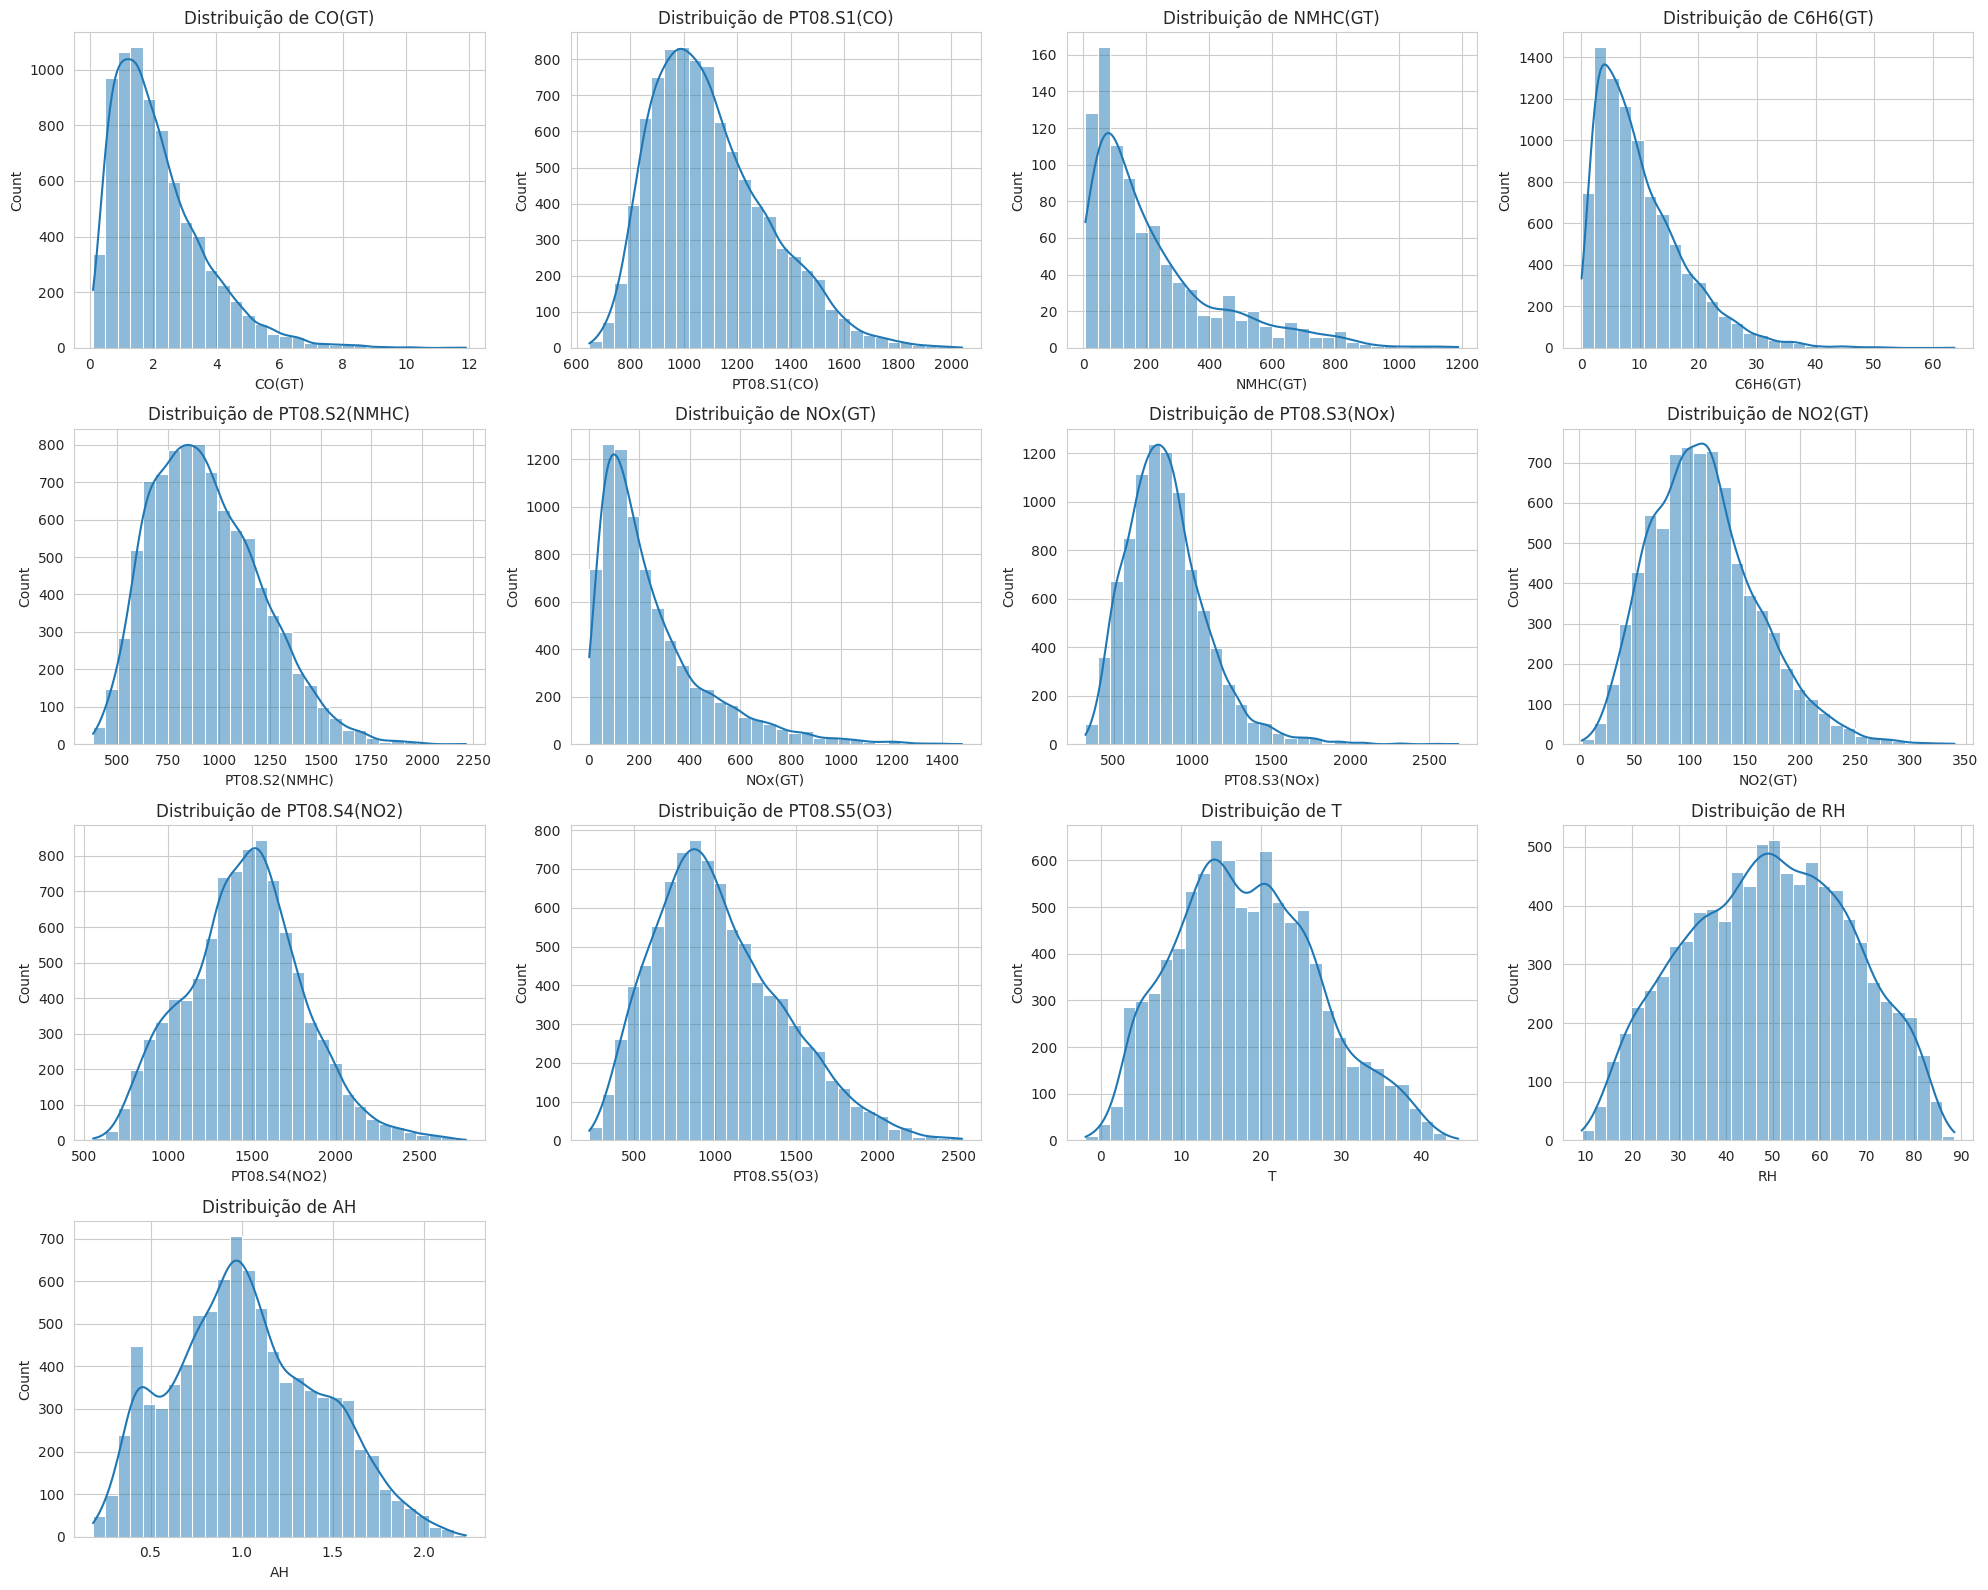

In [45]:
# Somente colunas numéricas
numeric_cols = air_quality.copy().select_dtypes(include=np.number).columns

# Define o layout da grade e o tamanho total da figura
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))

# Loop para criar histogramas para cada coluna numérica
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.histplot(data=air_quality, x=col, kde=True, bins=30, ax=ax)
    ax.set_title(f'Distribuição de {col}', fontsize=12)


# Esconde as colunas vazias
for i in range(len(numeric_cols), 16):
    axes.flatten()[i].axis('off')

# Espaçamento
plt.tight_layout()

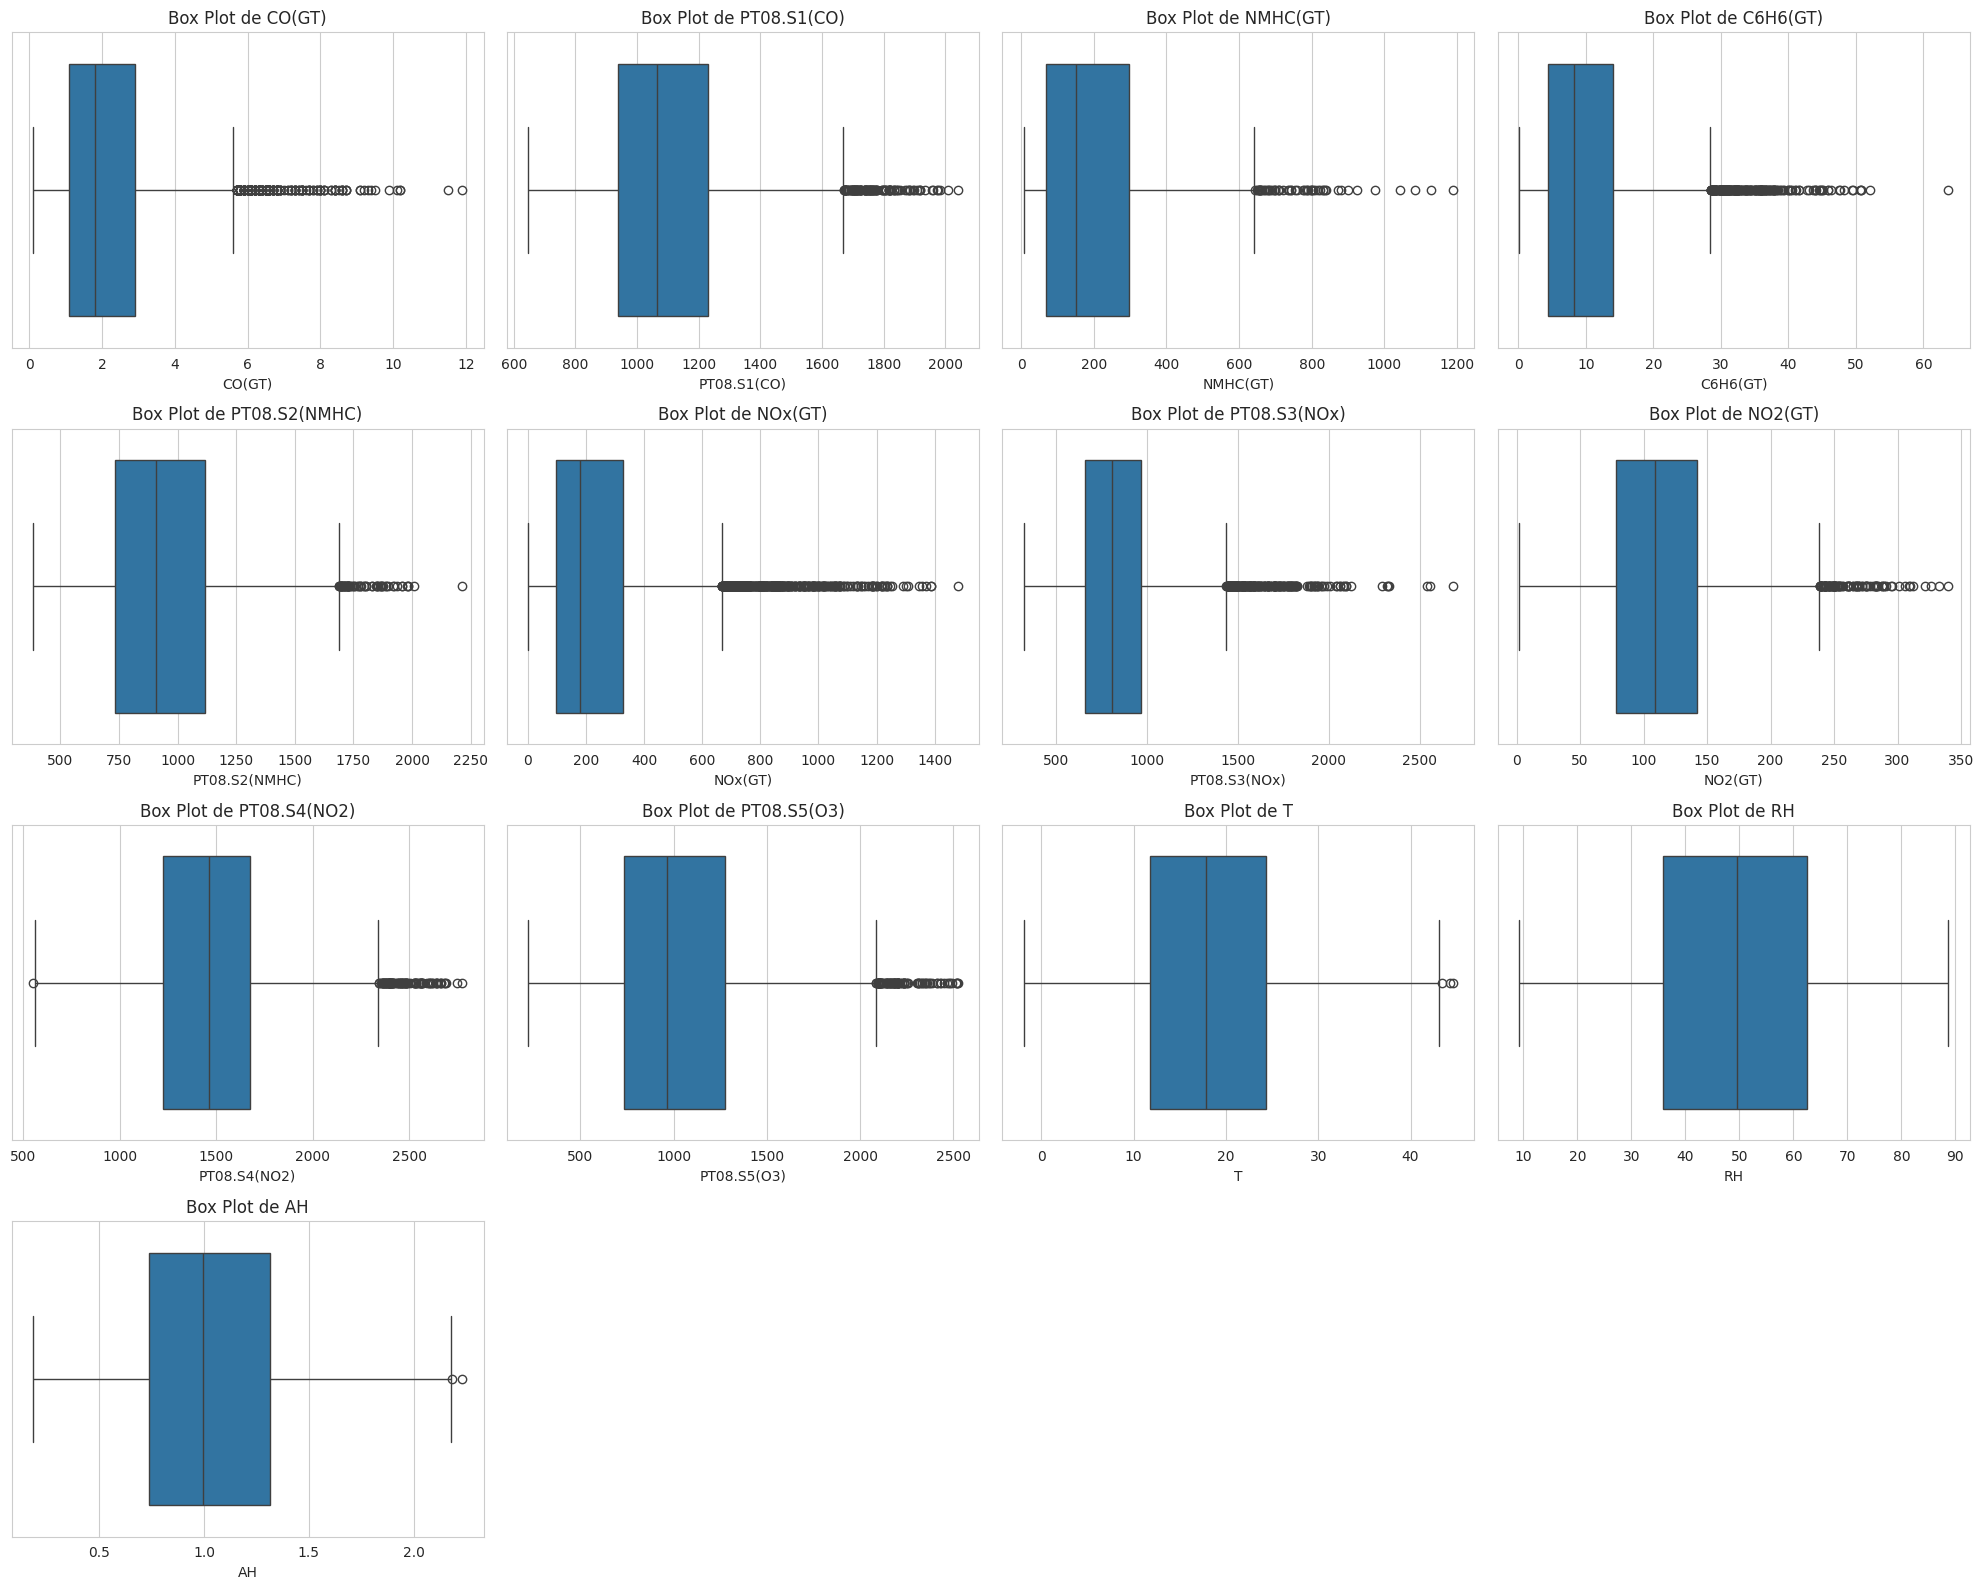

In [46]:
# Somente as colunas numéricas
numeric_cols = air_quality.select_dtypes(include=np.number).columns

# Define o layout da grade e o tamanho total da figura
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))

# Loop para criar box plots para cada coluna numérica
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(x=air_quality[col], ax=ax)
    ax.set_title(f'Box Plot de {col}', fontsize=12)

# Esconde as colunas vazias
for i in range(len(numeric_cols), 16):
    axes.flatten()[i].axis('off')

# Espaçamento
plt.tight_layout()

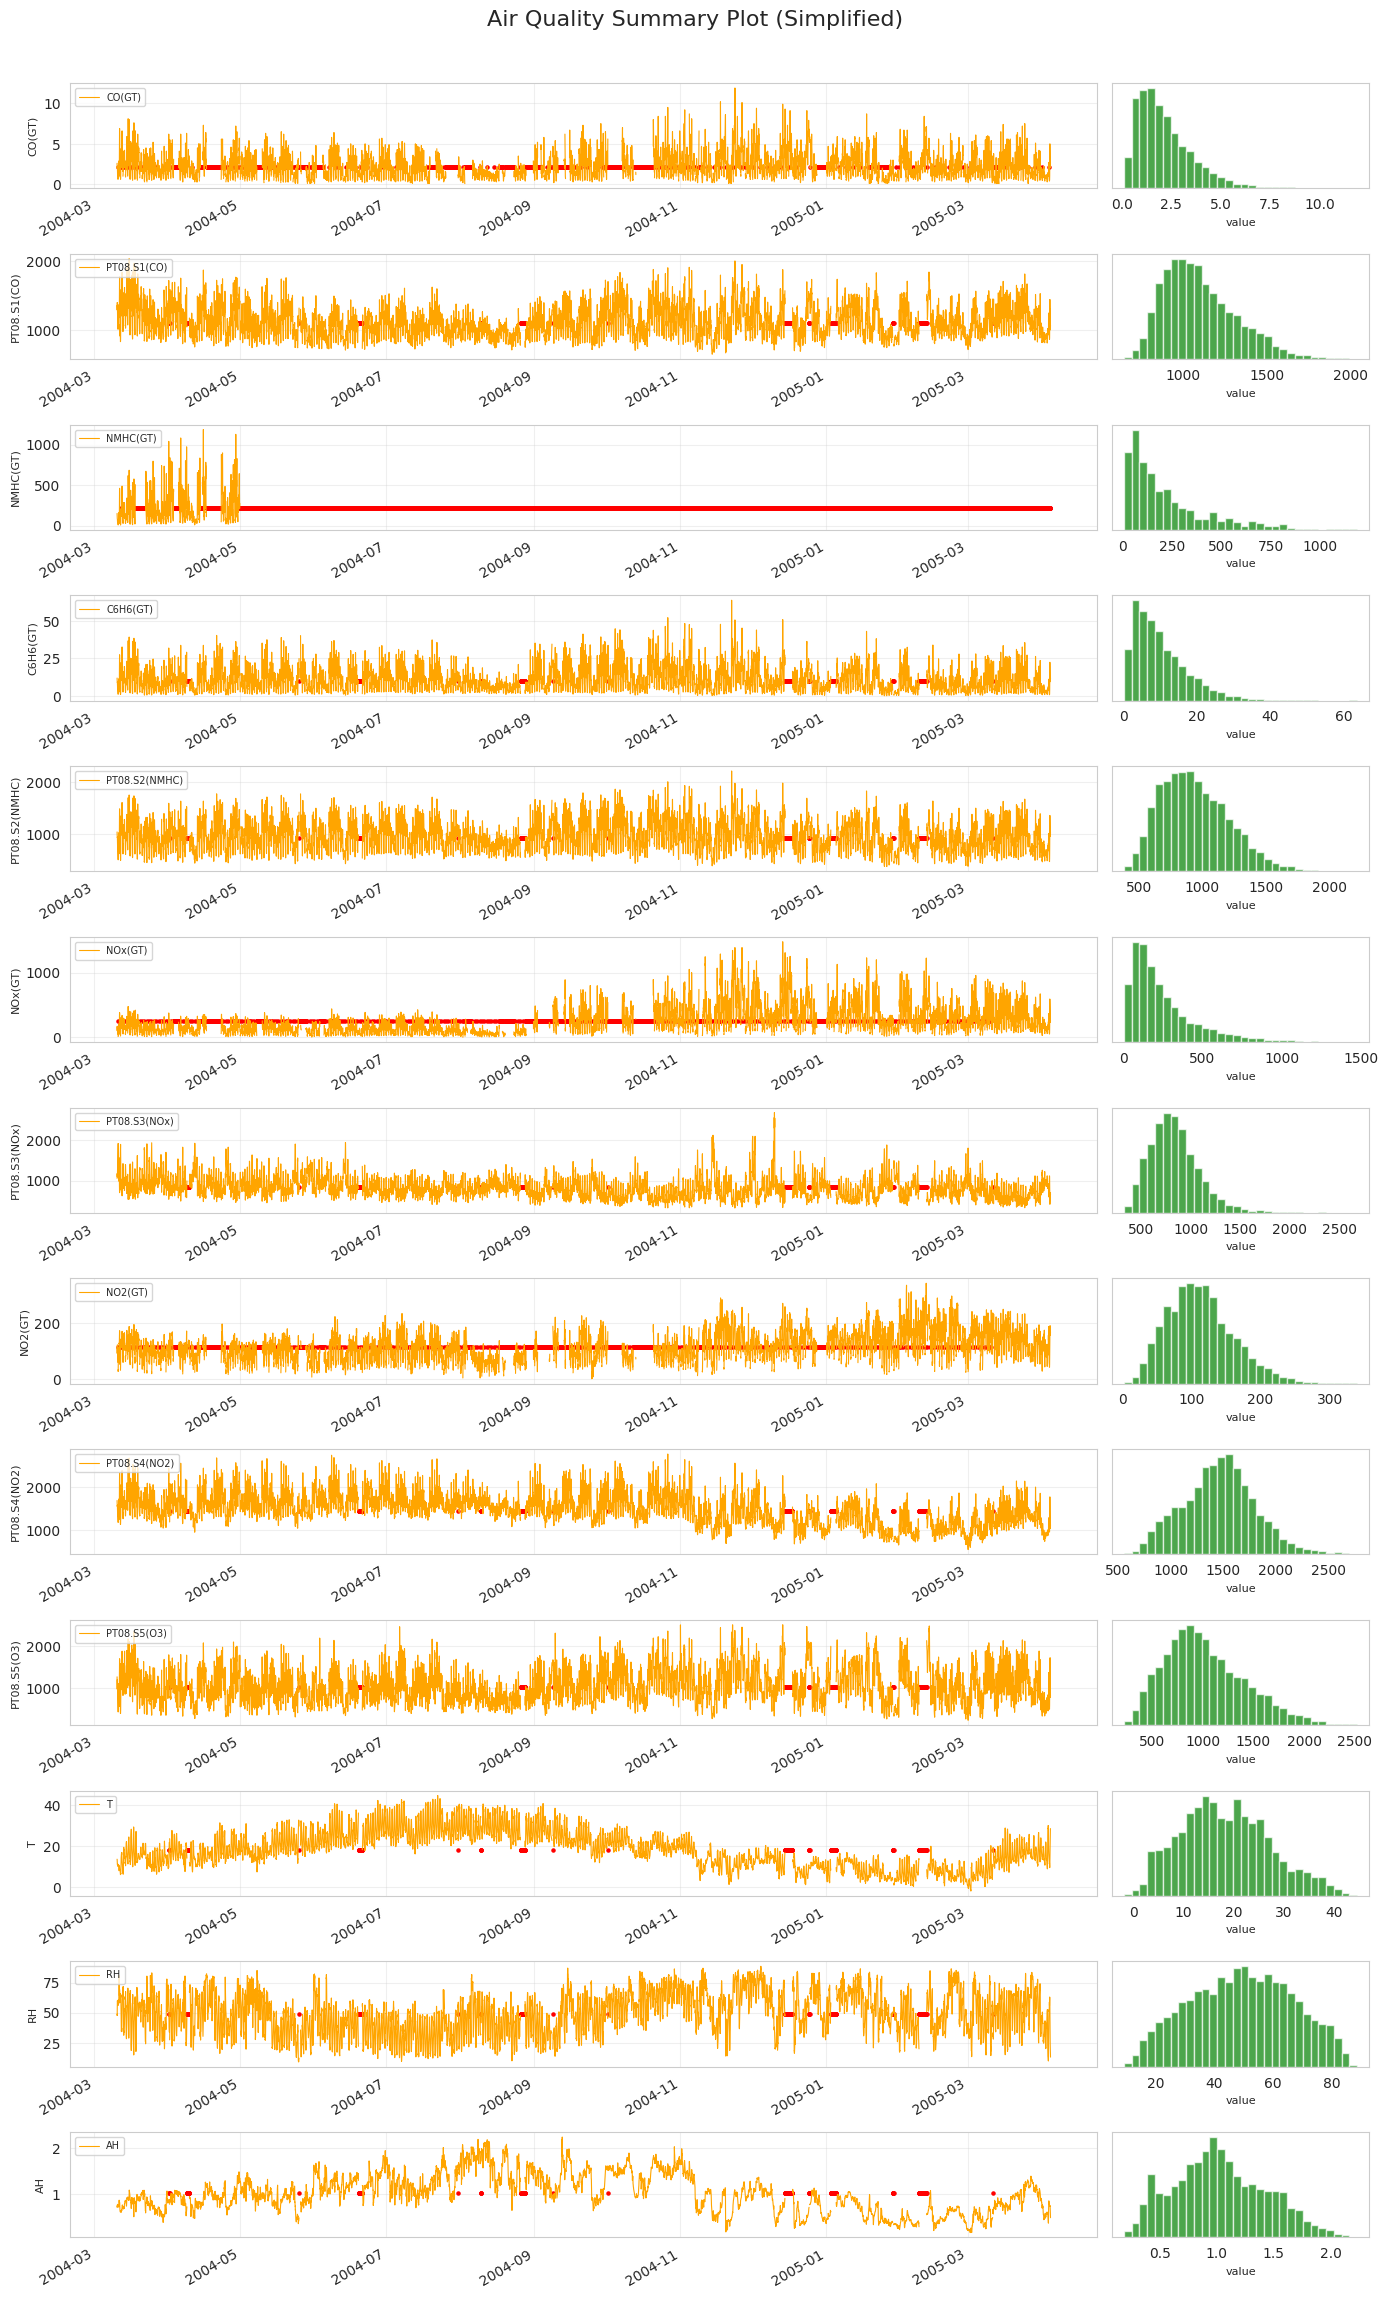

In [47]:
# Selecionar apenas colunas numéricas
cols = air_quality.select_dtypes("number").columns

# Criar figura
fig, axes = plt.subplots(nrows=len(cols), ncols=2, figsize=(14, len(cols) * 1.8),
                         gridspec_kw={"width_ratios": [4, 1]})
fig.suptitle("Air Quality Summary Plot (Simplified)", fontsize=16)

for i, col in enumerate(cols):
    # --- Série temporal ---
    ax_ts = axes[i, 0]
    air_quality[col].plot(ax=ax_ts, lw=0.8, color="orange", label=col)
    ax_ts.set_ylabel(col, fontsize=8)
    ax_ts.set_xlabel("")
    ax_ts.legend(loc="upper left", fontsize=7)
    ax_ts.grid(True, alpha=0.3)
    
    # Destacar valores faltantes
    na_mask = air_quality[col].isna()
    ax_ts.scatter(air_quality.index[na_mask], [air_quality[col].mean()]*na_mask.sum(),
                  color="red", s=5, label="missing")
    
    # --- Histograma ---
    ax_hist = axes[i, 1]
    air_quality[col].hist(ax=ax_hist, bins=30, color="green", alpha=0.7)
    ax_hist.set_ylabel("")
    ax_hist.set_xlabel("value", fontsize=8)
    ax_hist.grid(False)
    ax_hist.tick_params(axis="y", labelleft=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [48]:
air_quality_targets = air_quality[
    [
        "CO(GT)",      # Monóxido de carbono (mg/m³)
        "NMHC(GT)",    # Hidrocarbonetos não metânicos (µg/m³)
        "C6H6(GT)",    # Benzeno (µg/m³)
        "NOx(GT)",     # Óxidos de nitrogênio totais (ppb)
        "NO2(GT)"      # Dióxido de nitrogênio (µg/m³)
    ]
]

air_quality_predictors = air_quality[
    [
        "PT08.S1(CO)",     # Sensor 1 — SnO₂ (CO)
        "PT08.S2(NMHC)",   # Sensor 2 — TiO₂ (NMHC)
        "PT08.S3(NOx)",    # Sensor 3 — WO₃ (NOx)
        "PT08.S4(NO2)",    # Sensor 4 — WO₃ (NO₂)
        "PT08.S5(O3)",     # Sensor 5 — In₂O₃ (O₃)
        "T",               # Temperatura (°C)
        "RH",              # Umidade relativa (%)
        "AH"               # Umidade absoluta (g/m³)
    ]
]

In [49]:
air_quality

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.0,NaN,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
2005-04-04 11:00:00,2.4,1163.0,NaN,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
2005-04-04 12:00:00,2.4,1142.0,NaN,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406


#### 3.6 Criação das Classes

In [50]:
pollutants = ["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)"]

In [51]:
# Z-score normalization for CPI – Composite Pollution Index
air_quality = (
    air_quality
    .dropna(subset=pollutants)
    .assign(
        **{
            f"{p}_z": (air_quality[p] - air_quality[p].mean()) / air_quality[p].std()
            for p in pollutants
        }
    )
)

In [52]:
# Define pollution index as the mean of z-scores of selected pollutants
z_cols = [f"{p}_z" for p in pollutants]
air_quality["pollution_index"] = air_quality[z_cols].mean(axis=1)

In [53]:
# Categorize pollution index into Low, Moderate, High using quantiles
air_quality["pollution_class"] = pd.qcut(
    air_quality["pollution_index"], q=3, labels=["Low", "Moderate", "High"]
)

In [54]:
# Display the first few rows of the DataFrame with the new columns
air_quality["pollution_class"].value_counts()

pollution_class
Low         2314
High        2314
Moderate    2313
Name: count, dtype: int64

In [55]:
# Create an ordered categorical month column
air_quality["month"] = pd.Categorical(
    air_quality.index.month_name().str[:3].str.lower(),
    categories=["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"],
    ordered=True
)

In [56]:
# Create an ordered categorical weekday column
air_quality["weekday"] = pd.Categorical(
    air_quality.index.day_name().str[:3].str.lower(),
    categories=["mon","tue","wed","thu","fri","sat","sun"],
    ordered=True
)

In [57]:
# Create a categorical day period column based on hour of the day
hours = air_quality.index.hour
air_quality["day_period"] = pd.cut(hours, bins=[0, 6, 12, 18, 24],labels=["ngt", "mng", "aft", "eve"], right=False, include_lowest=True)

In [58]:
air_quality

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)_z,NOx(GT)_z,NO2(GT)_z,C6H6(GT)_z,pollution_index,pollution_class,month,weekday,day_period
datetime,,,,,,,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,0.307634,-0.379834,-0.001887,0.243884,0.042450,Moderate,mar,wed,eve
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,-0.105229,-0.675638,-0.436039,-0.091694,-0.327150,Moderate,mar,wed,eve
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,0.032392,-0.544169,0.018787,-0.145387,-0.159594,Moderate,mar,wed,eve
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,0.032392,-0.351662,0.184179,-0.118540,-0.063408,Moderate,mar,wed,eve
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,-0.380472,-0.544169,0.060135,-0.480965,-0.336368,Moderate,mar,wed,eve
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.0,NaN,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568,0.651687,1.056926,1.590006,0.458655,0.939318,High,apr,mon,mng
2005-04-04 11:00:00,2.4,1163.0,NaN,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119,0.170013,0.498186,1.362593,0.176769,0.551890,High,apr,mon,mng
2005-04-04 12:00:00,2.4,1142.0,NaN,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406,0.170013,0.216468,1.279897,0.311000,0.494345,High,apr,mon,aft


# 4. Estátisticas univariadas condicionada por classes

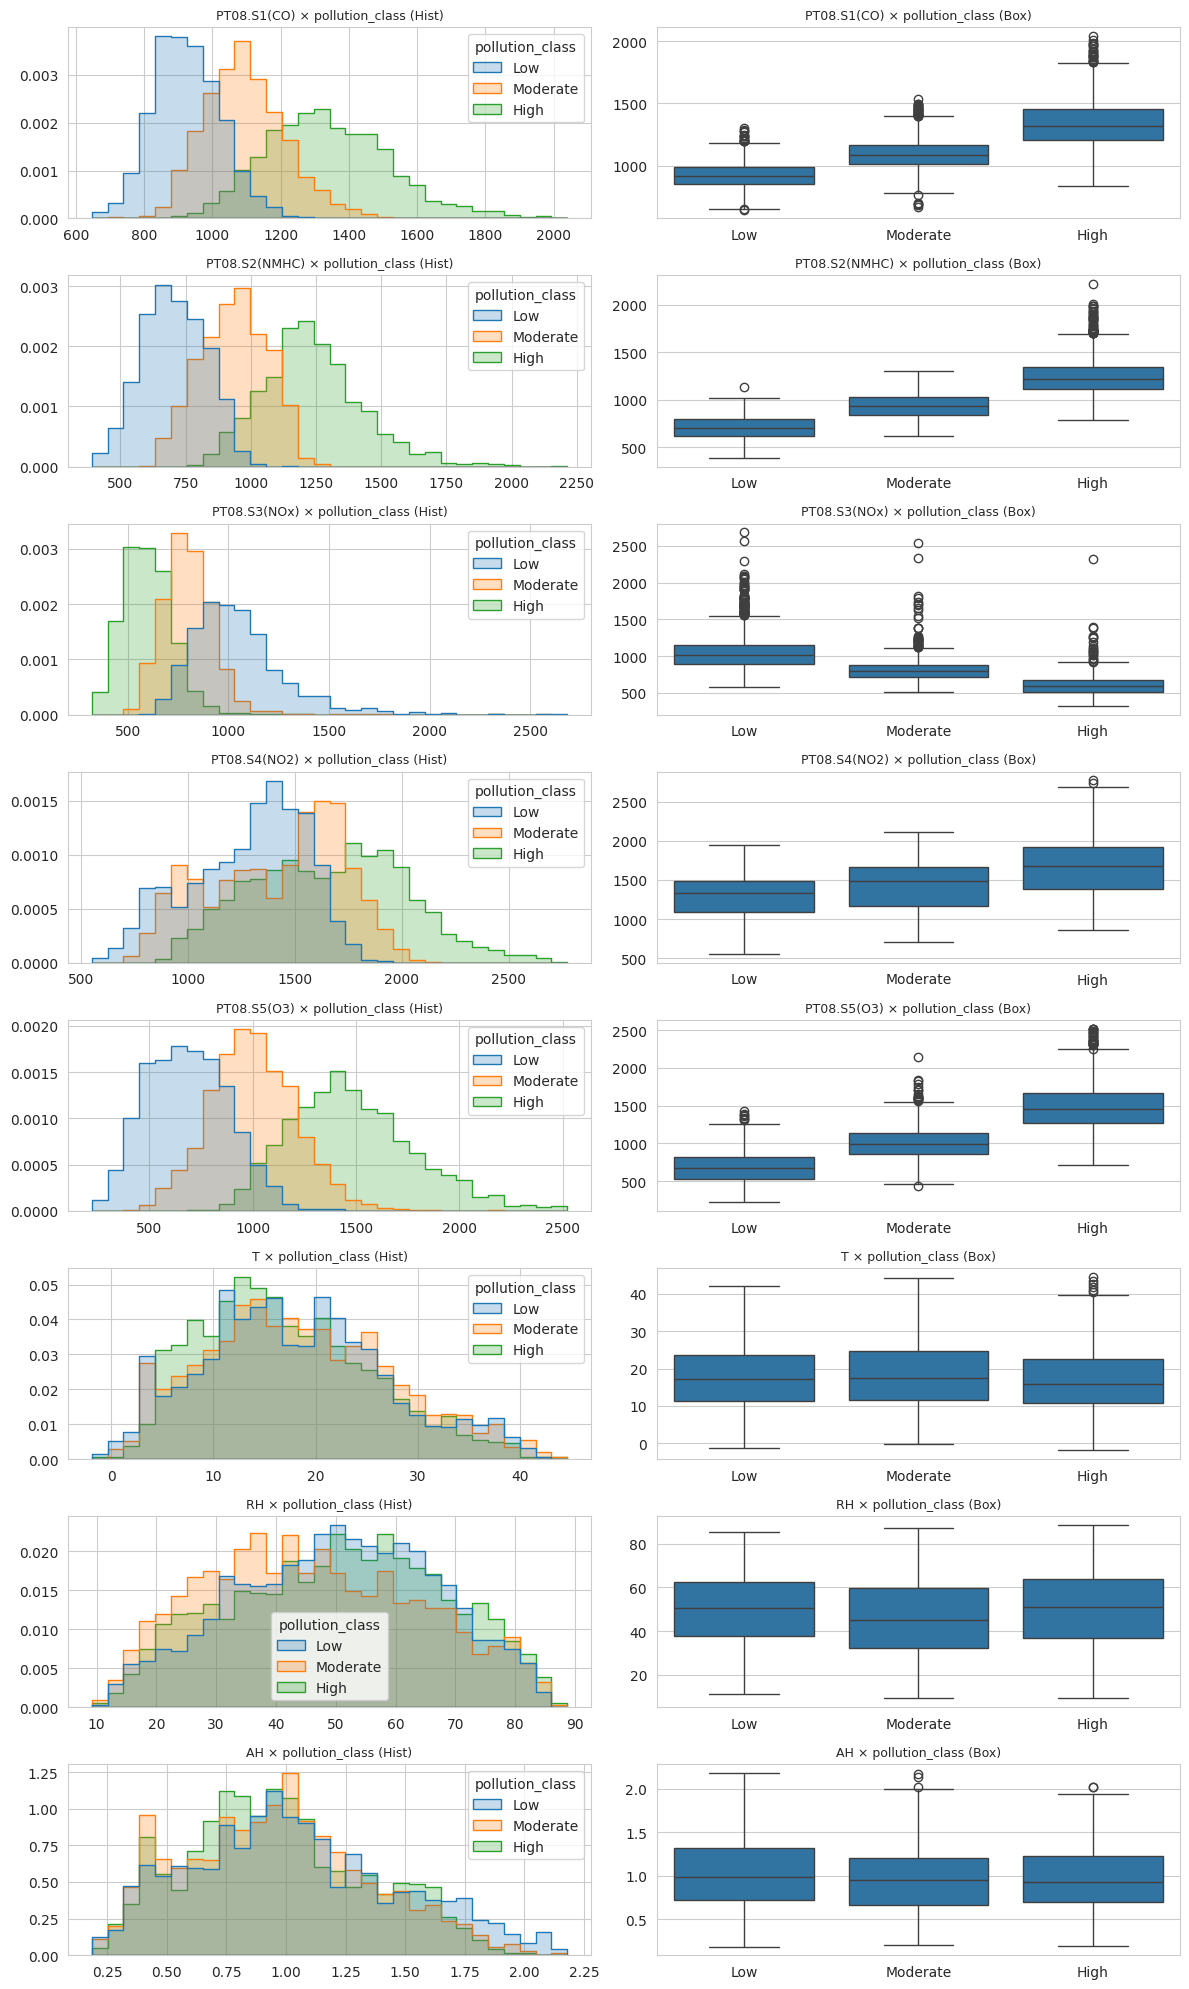

,pollution_class,PT08.S1(CO)_mean,PT08.S1(CO)_std,PT08.S1(CO)_skew,PT08.S2(NMHC)_mean,PT08.S2(NMHC)_std,PT08.S2(NMHC)_skew,PT08.S3(NOx)_mean,PT08.S3(NOx)_std,PT08.S3(NOx)_skew,PT08.S4(NO2)_mean,PT08.S4(NO2)_std,PT08.S4(NO2)_skew,PT08.S5(O3)_mean,PT08.S5(O3)_std,PT08.S5(O3)_skew,T_mean,T_std,T_skew,RH_mean,RH_std,RH_skew,AH_mean,AH_std,AH_skew
0,Low,926.0203,98.7296,0.2732,706.1616,120.9149,0.0067,1047.1223,231.9495,1.4434,1281.5843,269.9285,-0.4265,686.8111,197.9975,0.2582,17.8860,9.0472,0.3375,50.1073,16.5722,-0.1303,1.0345,0.4347,0.3576
1,Moderate,1094.6602,119.2685,0.3580,934.0796,127.3961,-0.0872,804.5011,140.1386,2.6137,1414.3390,311.7375,-0.2891,1002.0450,208.1723,0.3154,18.3569,9.1295,0.3305,46.1765,17.8384,0.2093,0.9567,0.3870,0.3037
2,High,1339.0484,182.4781,0.4596,1235.3773,193.3117,0.6123,599.0514,127.6545,1.7852,1662.0069,360.4541,0.1423,1484.3894,300.7399,0.5543,17.0233,8.2856,0.5185,50.3607,17.5546,-0.1000,0.9655,0.3747,0.3029


In [ ]:
predictors = ["PT08.S1(CO)","PT08.S2(NMHC)","PT08.S3(NOx)","PT08.S4(NO2)","PT08.S5(O3)","T","RH","AH"]

fig, axes = plt.subplots(len(predictors), 2, figsize=(12, len(predictors)*2.5))
for i, col in enumerate(predictors):
    sns.histplot(data=air_quality, x=col, hue="pollution_class", element="step", stat="density", common_norm=False, bins=30, ax=axes[i,0])
    axes[i,0].set_title(f"{col} × pollution_class (Hist)", fontsize=9)
    axes[i,0].set_xlabel(""); axes[i,0].set_ylabel("")
    sns.boxplot(data=air_quality, x="pollution_class", y=col, ax=axes[i,1])
    axes[i,1].set_title(f"{col} × pollution_class (Box)", fontsize=9)
    axes[i,1].set_xlabel(""); axes[i,1].set_ylabel("")
plt.tight_layout()
plt.show()

stats = air_quality.groupby("pollution_class")[predictors].agg(["mean","std","skew"])
stats.columns = ["_".join(col) for col in stats.columns]
stats = stats.reset_index().round(4)
display(stats)



=== MONTH ===



,PT08.S1(CO)_mean,PT08.S1(CO)_std,PT08.S1(CO)_skew,PT08.S2(NMHC)_mean,PT08.S2(NMHC)_std,PT08.S2(NMHC)_skew,PT08.S3(NOx)_mean,PT08.S3(NOx)_std,PT08.S3(NOx)_skew,PT08.S4(NO2)_mean,PT08.S4(NO2)_std,PT08.S4(NO2)_skew,PT08.S5(O3)_mean,PT08.S5(O3)_std,PT08.S5(O3)_skew,T_mean,T_std,T_skew,RH_mean,RH_std,RH_skew,AH_mean,AH_std,AH_skew
month,,,,,,,,,,,,,,,,,,,,,,,,
jan,1137.418919,222.318144,0.430132,928.375000,272.413015,0.373439,752.569257,235.510085,0.688722,1185.141892,283.095806,0.391966,1149.868243,457.014363,0.169388,8.535980,3.858803,0.171217,56.425169,14.416239,-0.298283,0.646617,0.230365,0.116344
feb,1092.951872,195.409596,1.131831,851.771836,225.523584,0.642160,782.351159,206.189094,0.658704,1062.490196,217.241243,0.772223,1041.827094,440.522422,0.707333,7.277540,3.489750,0.488652,51.385027,17.159447,0.273949,0.516114,0.149444,0.605736
mar,1188.764159,217.884738,0.639115,923.545224,252.535286,0.517824,818.763314,270.215753,0.900731,1378.064243,326.051587,0.401193,1081.532544,394.826984,0.357186,13.918597,5.705582,-0.063305,50.097295,15.816456,-0.138485,0.787202,0.243231,-0.162294
apr,1153.492509,241.165842,0.556422,933.900749,279.107784,0.388520,913.500000,253.357986,0.929388,1521.838951,377.109532,0.126192,978.977528,418.424737,0.313709,16.875468,4.819334,0.624403,46.624719,16.030738,0.139866,0.851737,0.205190,0.449622
may,1101.423550,193.366474,0.610625,978.996485,226.385686,0.364779,911.119508,215.603884,0.601544,1628.202109,259.426608,0.780488,958.008787,323.047284,0.561747,20.939543,5.056393,0.513492,42.083831,16.547752,0.244229,0.965424,0.209304,-0.243398
jun,1038.570175,162.168411,0.252610,990.585965,240.464417,0.167627,871.707018,207.349827,1.013810,1742.673684,256.128302,0.707355,961.978947,316.280819,0.534083,27.163509,6.034666,0.481269,38.287544,13.574573,0.363592,1.276032,0.204588,0.090987
jul,1054.300935,154.483012,0.553882,980.921495,221.942702,0.314540,803.785047,161.731249,0.445423,1655.031776,224.692576,0.875699,1007.626168,359.540878,0.561181,29.479439,6.249724,0.339850,32.957570,12.954120,0.168157,1.241261,0.255109,0.392490
aug,982.340686,110.309679,0.196259,842.426471,142.987653,0.315510,833.154412,147.612742,0.500184,1589.904412,172.696203,0.302766,774.781863,222.284739,0.759379,29.906618,5.174425,0.202527,41.936520,14.514247,0.023215,1.650275,0.305363,-0.527317
sep,1090.363636,204.244125,0.462064,1032.663636,274.519005,0.351329,803.536364,217.119984,0.598709,1557.495455,294.560195,0.766031,1078.315909,357.687221,0.475452,23.704545,5.178467,0.286156,43.875455,14.019249,0.133868,1.226242,0.280074,0.000829


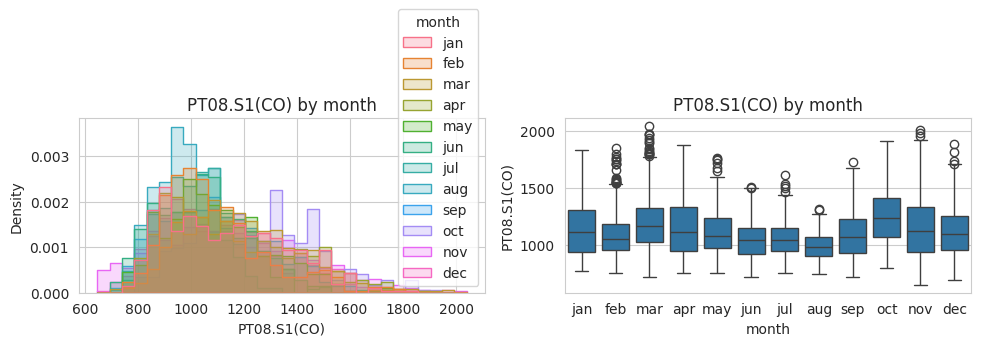

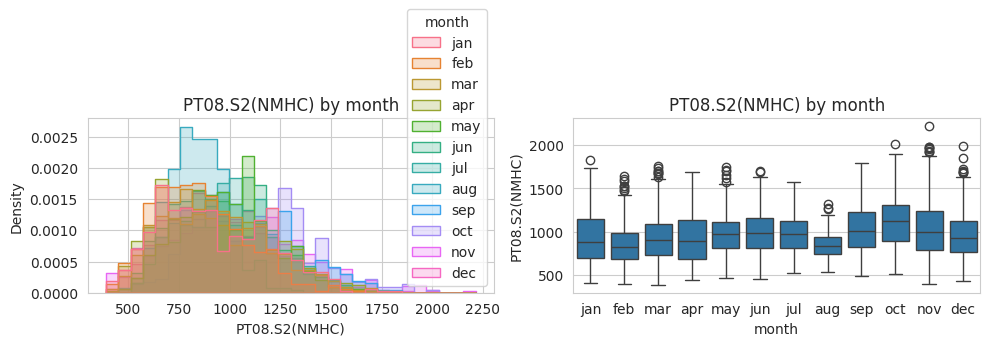

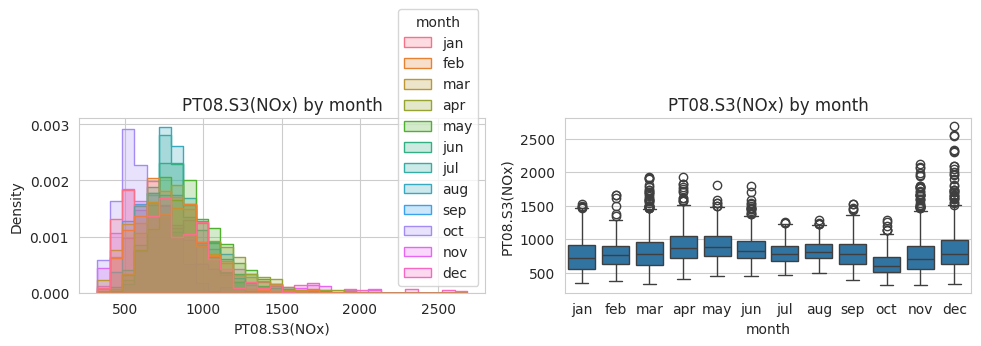

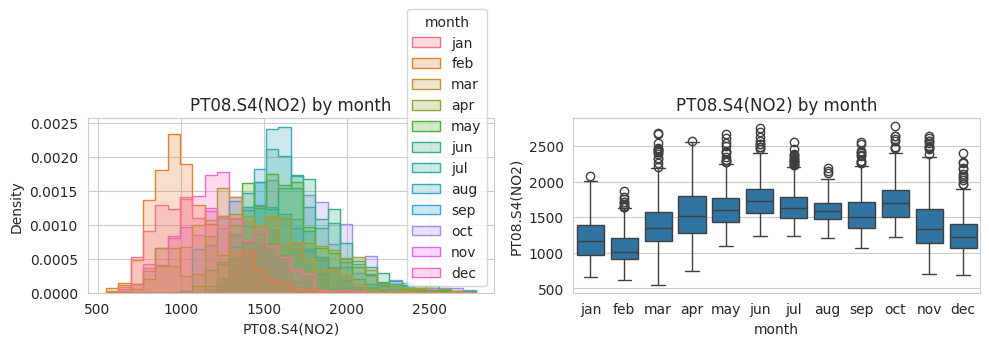

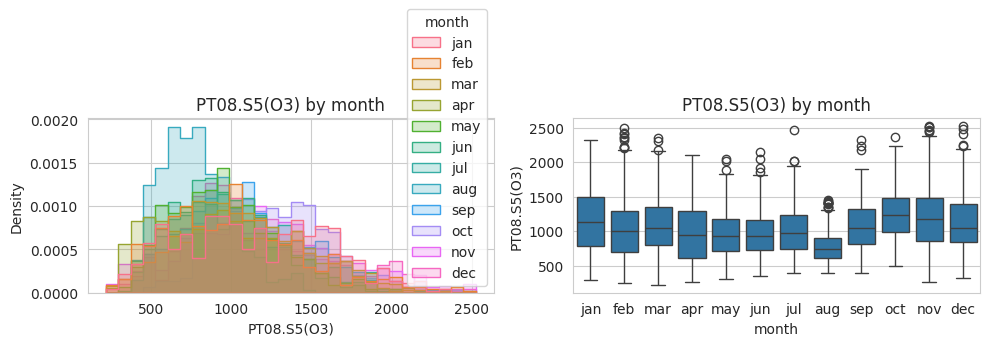

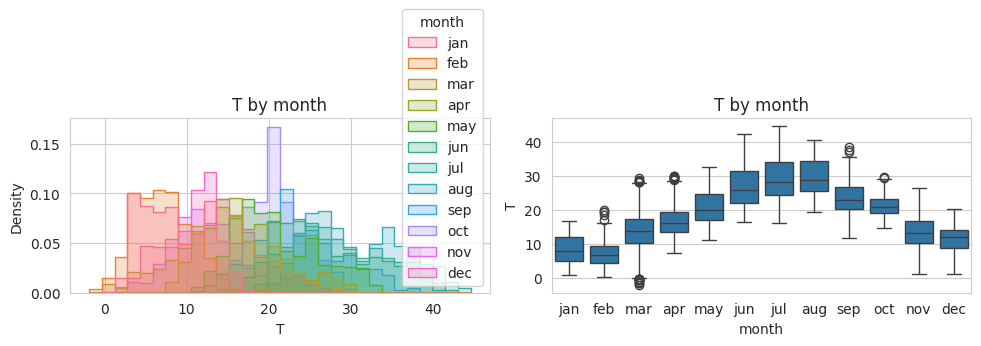

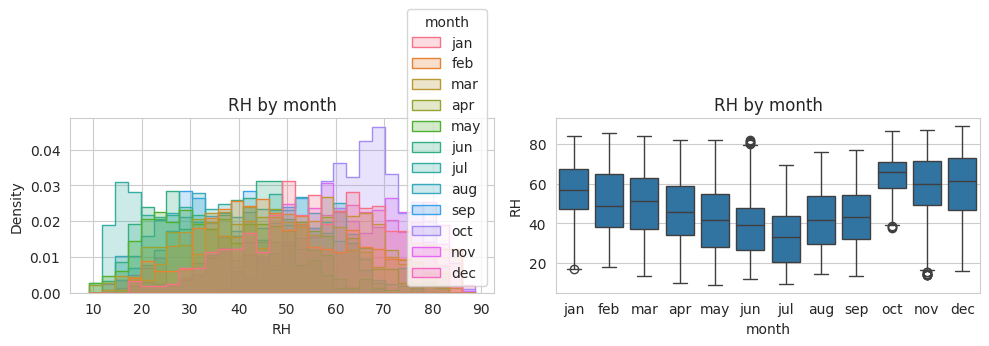

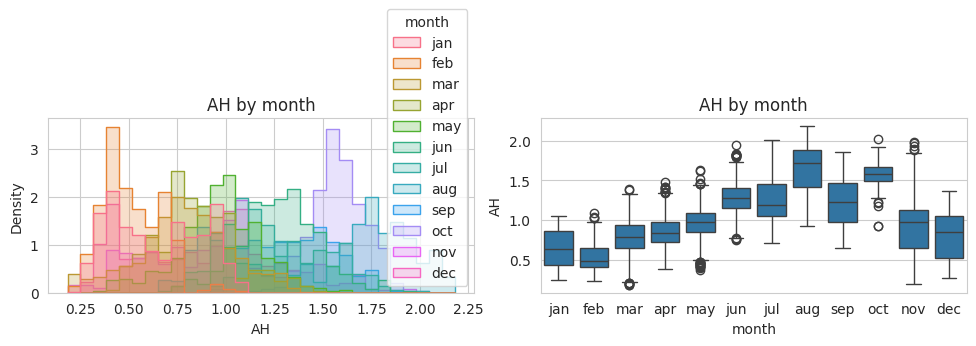


=== WEEKDAY ===



,PT08.S1(CO)_mean,PT08.S1(CO)_std,PT08.S1(CO)_skew,PT08.S2(NMHC)_mean,PT08.S2(NMHC)_std,PT08.S2(NMHC)_skew,PT08.S3(NOx)_mean,PT08.S3(NOx)_std,PT08.S3(NOx)_skew,PT08.S4(NO2)_mean,PT08.S4(NO2)_std,PT08.S4(NO2)_skew,PT08.S5(O3)_mean,PT08.S5(O3)_std,PT08.S5(O3)_skew,T_mean,T_std,T_skew,RH_mean,RH_std,RH_skew,AH_mean,AH_std,AH_skew
weekday,,,,,,,,,,,,,,,,,,,,,,,,
mon,1082.140777,213.189150,1.002593,942.658252,277.888603,0.641505,843.904854,260.607630,0.948449,1418.708738,359.492765,0.243875,1000.819417,423.455867,0.841894,17.495728,8.503274,0.403845,46.369029,16.861483,0.147987,0.931322,0.399089,0.398632
tue,1141.191398,232.970156,0.591907,1014.546237,300.080952,0.300173,792.281720,250.297739,0.893093,1507.964516,401.024267,0.115748,1125.792473,425.632698,0.432545,17.444194,8.898050,0.316334,47.983763,17.499903,0.034963,0.956171,0.399072,0.231843
wed,1157.406250,209.586746,0.647972,1018.625000,265.618855,0.314366,776.247845,246.260400,1.435254,1516.442888,363.222739,0.191769,1154.683190,381.795317,0.452540,17.939871,9.386968,0.382337,49.899569,18.007786,-0.107028,1.009232,0.402890,0.389853
thu,1171.755123,215.331174,0.625241,1017.254098,269.260444,0.302634,767.786885,246.127825,1.564214,1525.692623,355.758151,0.211315,1155.496926,383.539275,0.347765,18.034734,9.263122,0.452961,50.816189,17.130965,-0.095291,1.036943,0.404925,0.440104
fri,1174.280876,227.676680,0.468919,1030.807769,262.200231,0.154180,759.867530,250.725920,2.321155,1537.312749,347.573015,0.007757,1156.821713,403.174310,0.397932,18.285060,8.491027,0.381963,50.395916,17.821105,-0.160640,1.031892,0.384984,0.330646
sat,1102.670423,205.739217,0.658935,910.463850,189.991054,0.248990,823.499531,209.999325,0.596443,1388.525822,292.043322,-0.308373,1011.239437,375.974931,0.643294,17.686761,8.723465,0.397656,48.478310,17.247512,0.039934,0.976140,0.395502,0.228594
sun,1018.231151,179.286601,0.993415,789.763889,175.487387,0.641295,946.786706,247.119431,0.907797,1290.259921,273.071244,-0.094394,819.768849,326.112867,0.907356,17.412004,8.669005,0.435283,48.386905,17.136966,0.044489,0.960443,0.410166,0.515733


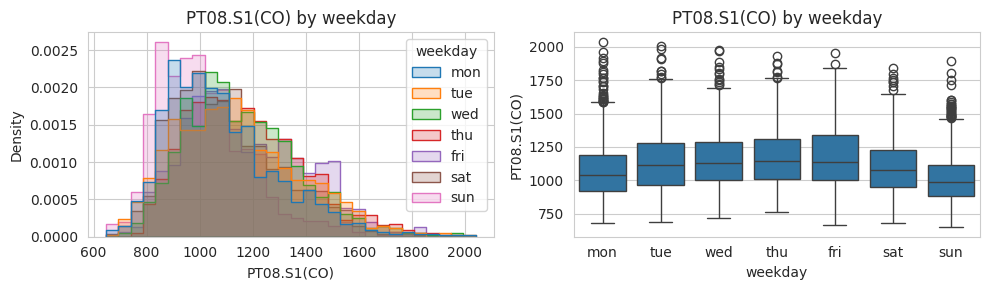

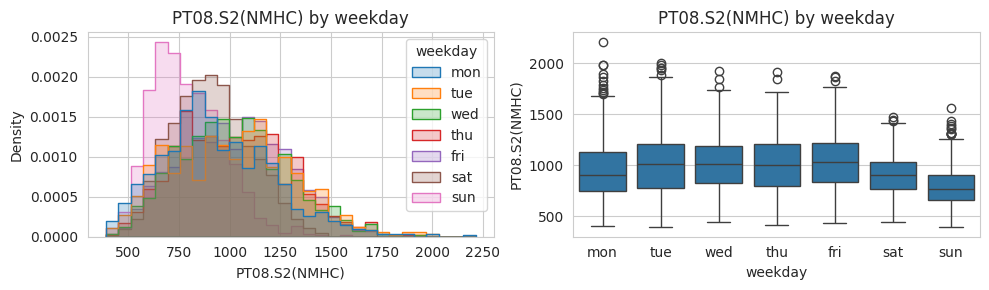

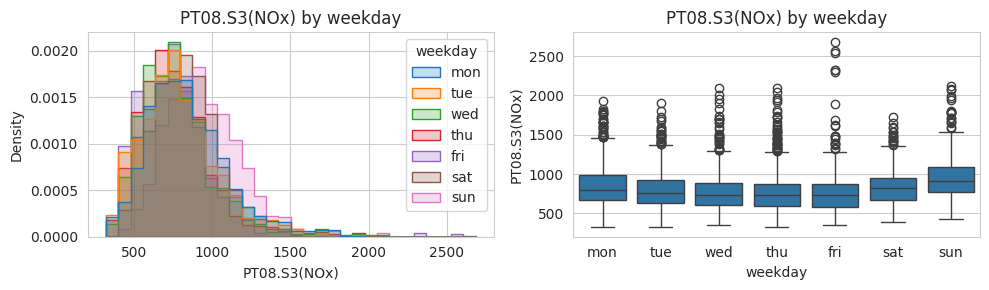

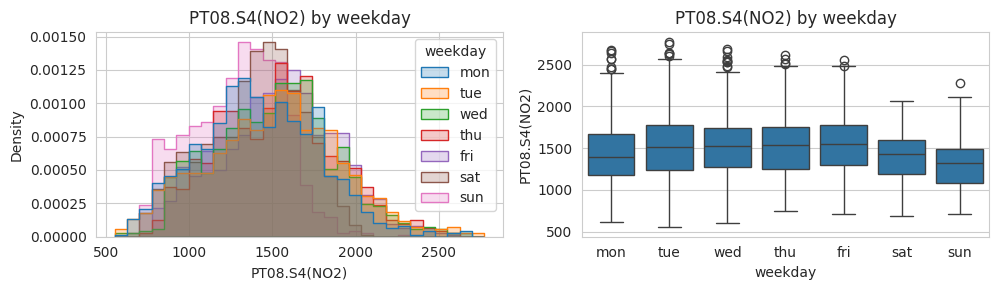

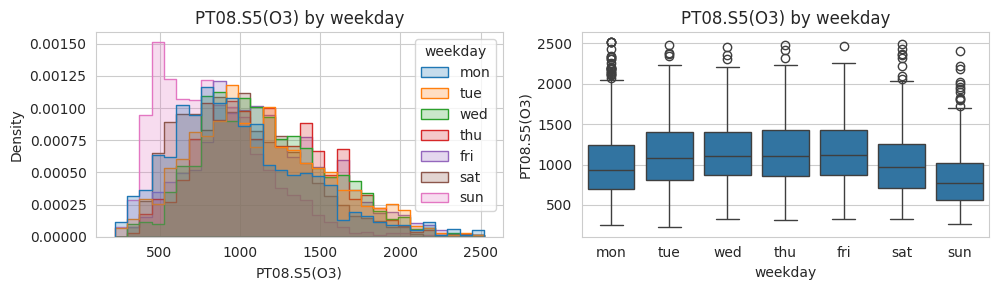

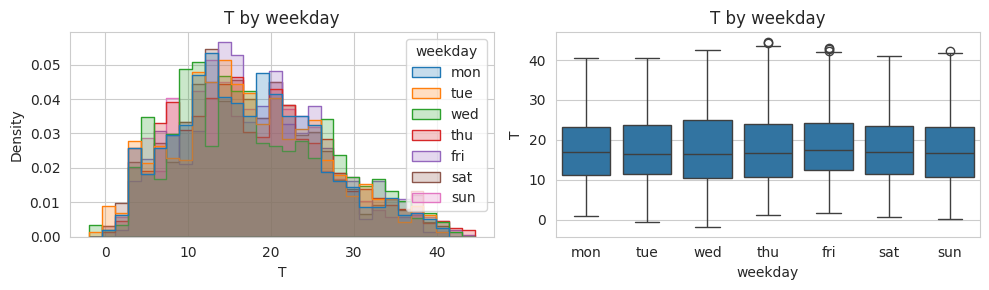

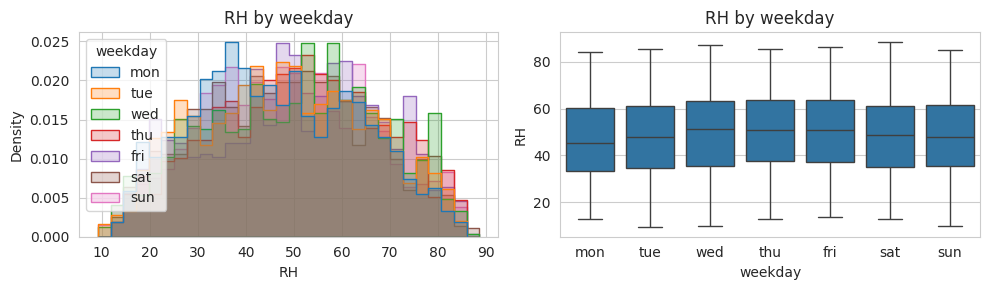

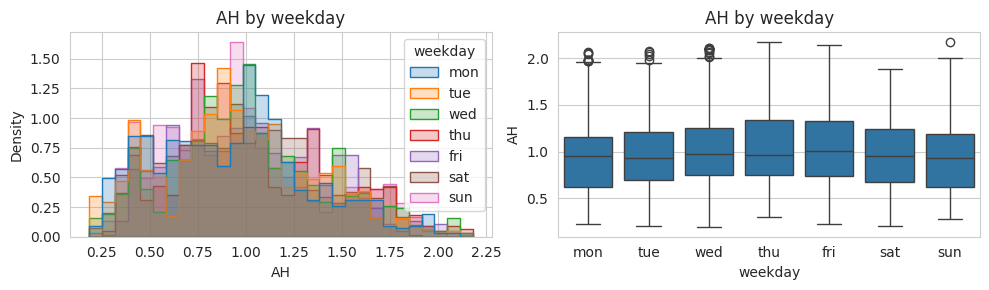


=== DAY_PERIOD ===



,PT08.S1(CO)_mean,PT08.S1(CO)_std,PT08.S1(CO)_skew,PT08.S2(NMHC)_mean,PT08.S2(NMHC)_std,PT08.S2(NMHC)_skew,PT08.S3(NOx)_mean,PT08.S3(NOx)_std,PT08.S3(NOx)_skew,PT08.S4(NO2)_mean,PT08.S4(NO2)_std,PT08.S4(NO2)_skew,PT08.S5(O3)_mean,PT08.S5(O3)_std,PT08.S5(O3)_skew,T_mean,T_std,T_skew,RH_mean,RH_std,RH_skew,AH_mean,AH_std,AH_skew
day_period,,,,,,,,,,,,,,,,,,,,,,,,
ngt,974.389915,152.092215,1.029052,741.685369,165.299968,0.621510,978.085938,262.545292,1.115107,1274.887074,264.907895,-0.118199,851.262074,311.048513,0.848448,14.524006,6.993848,0.051483,58.147656,13.386172,-0.085463,1.007121,0.406136,0.351226
mng,1139.616386,219.383142,0.457124,980.841563,277.877469,0.324384,799.839935,264.704110,1.510213,1495.741183,386.393208,0.213614,1121.827455,403.147431,0.212192,15.932067,8.206202,0.253354,53.568041,15.548253,-0.096827,0.989511,0.401500,0.403385
aft,1135.286801,203.184571,0.518509,999.750679,224.390169,0.372502,790.553504,213.455653,0.786797,1455.989680,327.728282,-0.098900,1017.333514,405.871116,0.641054,21.962738,9.700025,0.250815,37.480771,17.120650,0.662408,0.949070,0.392924,0.375819
eve,1195.782044,224.653214,0.798940,1060.422931,256.010855,0.642870,737.370471,208.557737,1.038408,1541.734451,354.532532,0.097833,1191.385614,405.987665,0.535465,17.844078,8.175179,0.256759,48.506977,15.973218,0.211465,1.001583,0.402775,0.293816


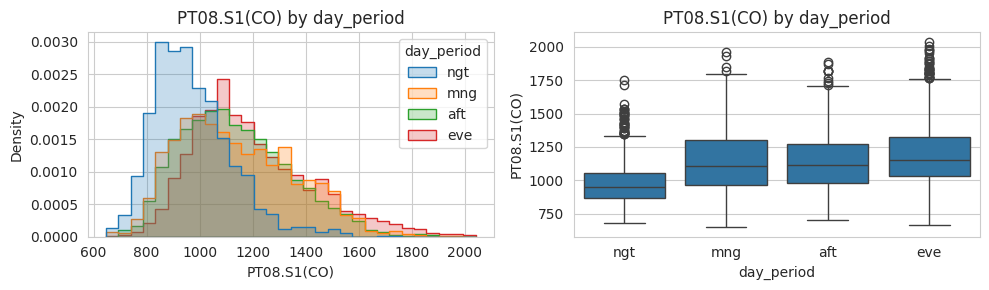

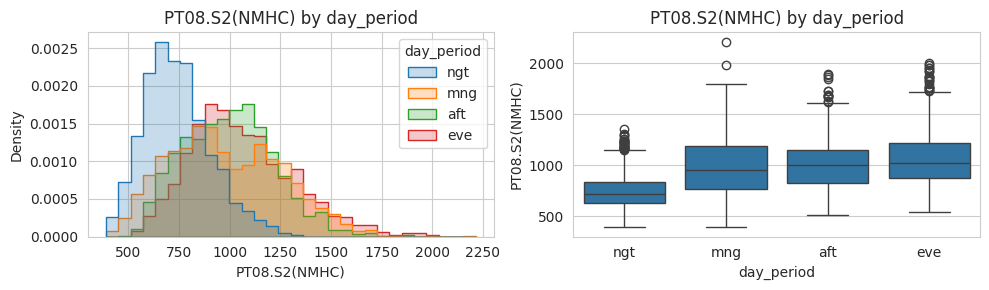

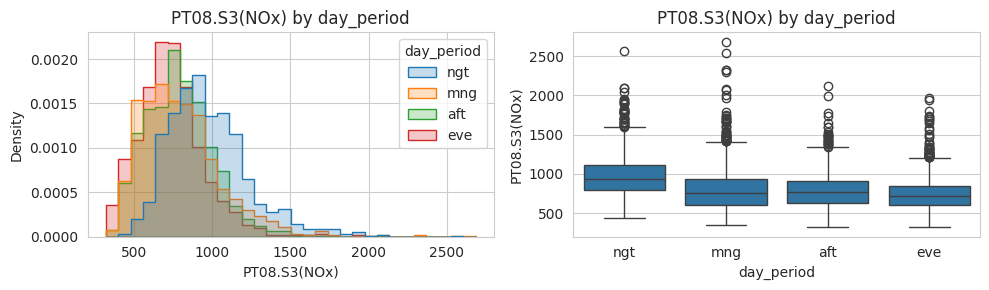

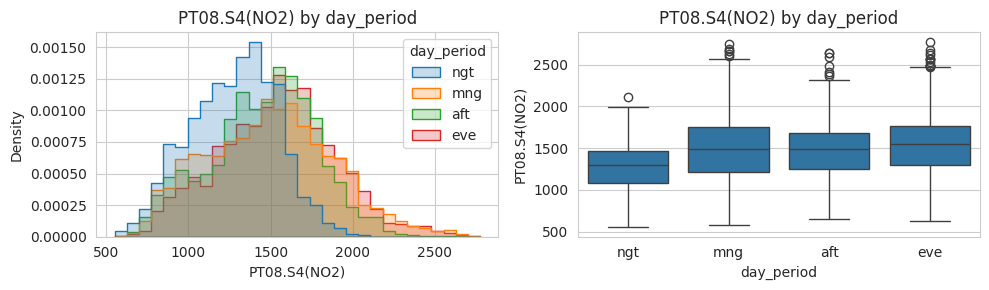

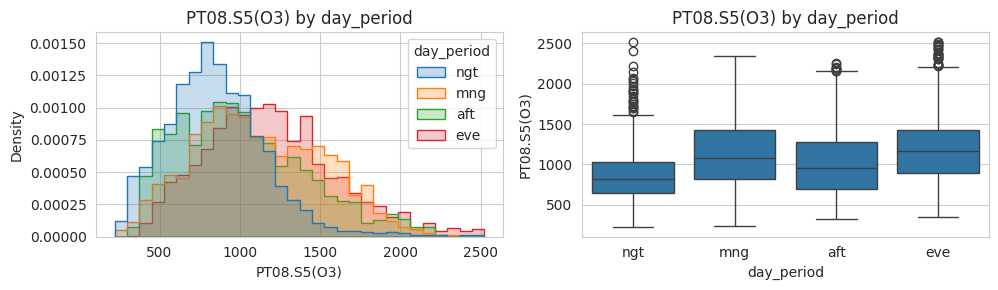

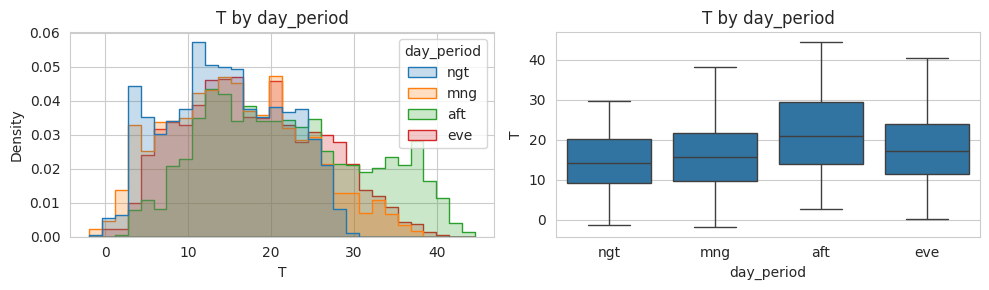

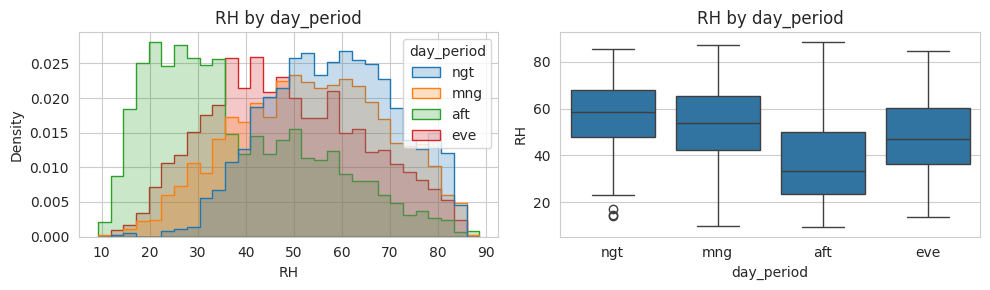

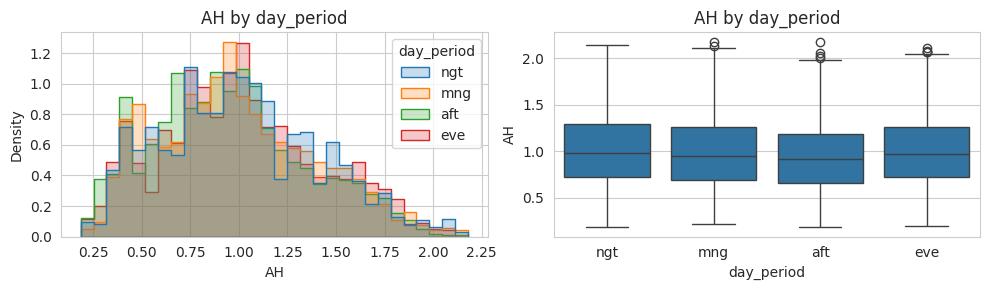

In [62]:
predictors = ["PT08.S1(CO)","PT08.S2(NMHC)","PT08.S3(NOx)","PT08.S4(NO2)","PT08.S5(O3)","T","RH","AH"]
temporal_classes = ["month", "weekday", "day_period"]

for cls in temporal_classes:
    print(f"\n=== {cls.upper()} ===\n")
    stats = air_quality.groupby(cls)[predictors].agg(["mean","std","skew"])
    stats.columns = ["_".join(col) for col in stats.columns]
    display(stats)
    for col in predictors:
        plt.figure(figsize=(10,3))
        plt.subplot(1,2,1)
        sns.histplot(data=air_quality, x=col, hue=cls, element="step", stat="density", common_norm=False, bins=30)
        plt.title(f"{col} by {cls}")
        plt.subplot(1,2,2)
        sns.boxplot(data=air_quality, x=cls, y=col)
        plt.title(f"{col} by {cls}")
        plt.tight_layout()
        plt.show()